# Analisis de datos sobre los lenguajes de programacion mas usados

Carga y analisis de los lenguajes de programacion mas populares segun el indice TIOBE de junio de 2026.

## Importacion de librerias

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Carga del dataset desde CSV

In [29]:
df = pd.read_csv('tiobe_junio_2026.csv')
df

,ranking_2026,ranking_2025,lenguaje,porcentaje,variacion,paradigma_principal
0,1,1,Python,18.96,-6.91,multiparadigma
1,2,3,C,10.77,1.30,imperativo
2,3,2,C++,8.03,-2.65,multiparadigma
3,4,4,Java,7.90,-0.94,orientado a objetos
4,5,5,C#,4.85,0.17,orientado a objetos
5,6,6,JavaScript,3.04,-0.17,multiparadigma
6,7,8,Visual Basic,2.80,0.59,orientado a eventos
7,8,12,SQL,1.77,0.23,declarativo
8,9,14,R,1.69,0.30,funcional
9,10,9,Delphi/Object Pascal,1.54,-0.60,orientado a objetos


## Informacion general del dataset

In [30]:
df.shape

(20, 6)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ranking_2026         20 non-null     int64  
 1   ranking_2025         20 non-null     int64  
 2   lenguaje             20 non-null     str    
 3   porcentaje           20 non-null     float64
 4   variacion            20 non-null     float64
 5   paradigma_principal  20 non-null     str    
dtypes: float64(2), int64(2), str(2)
memory usage: 1.1 KB


In [32]:
df.describe(include='all')

,ranking_2026,ranking_2025,lenguaje,porcentaje,variacion,paradigma_principal
count,20.00000,20.000000,20,20.000000,20.000000,20
unique,NaN,NaN,20,NaN,NaN,8
top,NaN,NaN,Python,NaN,NaN,multiparadigma
freq,NaN,NaN,1,NaN,NaN,8
mean,10.50000,10.750000,NaN,3.600000,-0.576000,NaN
std,5.91608,6.422616,NaN,4.610214,1.698053,NaN
min,1.00000,1.000000,NaN,0.850000,-6.910000,NaN
25%,5.75000,5.750000,NaN,0.992500,-0.782500,NaN
50%,10.50000,10.500000,NaN,1.500000,-0.125000,NaN
75%,15.25000,15.250000,NaN,3.492500,0.270000,NaN


## Valores nulos y duplicados

In [33]:
df.isnull().sum()

ranking_2026           0
ranking_2025           0
lenguaje               0
porcentaje             0
variacion              0
paradigma_principal    0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

## Top 10 de lenguajes mas usados

In [36]:
top_10 = df_limpio.sort_values('ranking_2026').head(10)
top_10

,ranking_2026,ranking_2025,lenguaje,porcentaje,variacion,paradigma_principal
0,1,1,Python,18.96,-6.91,multiparadigma
1,2,3,C,10.77,1.30,imperativo
2,3,2,C++,8.03,-2.65,multiparadigma
3,4,4,Java,7.90,-0.94,orientado a objetos
4,5,5,C#,4.85,0.17,orientado a objetos
5,6,6,JavaScript,3.04,-0.17,multiparadigma
6,7,8,Visual Basic,2.80,0.59,orientado a eventos
7,8,12,SQL,1.77,0.23,declarativo
8,9,14,R,1.69,0.30,funcional
9,10,9,Delphi/Object Pascal,1.54,-0.60,orientado a objetos


## EDA: distribuciones, outliers y relaciones entre variables
Se exploran variables numericas del dataset: `porcentaje`, `variacion`, `ranking_2026` y `ranking_2025`.

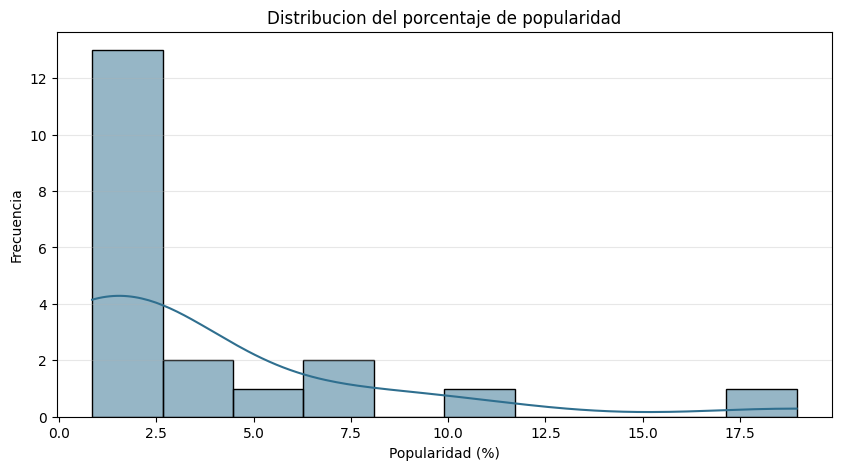

In [37]:
plt.figure(figsize=(10, 5))
sns.histplot(df_limpio['porcentaje'], bins=10, kde=True, color='#2f6f8f')
plt.title('Distribucion del porcentaje de popularidad')
plt.xlabel('Popularidad (%)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

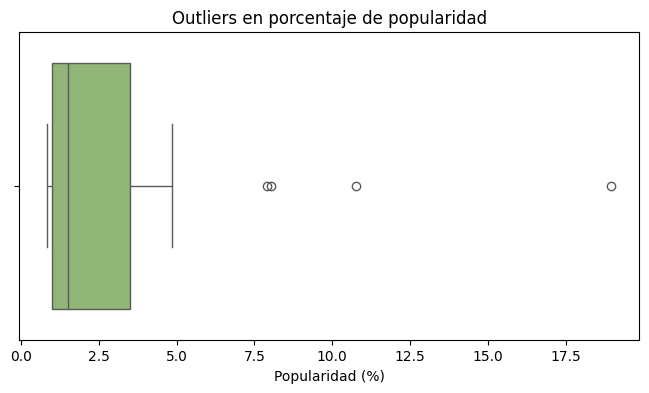

In [38]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_limpio, x='porcentaje', color='#90be6d')
plt.title('Outliers en porcentaje de popularidad')
plt.xlabel('Popularidad (%)')
plt.show()

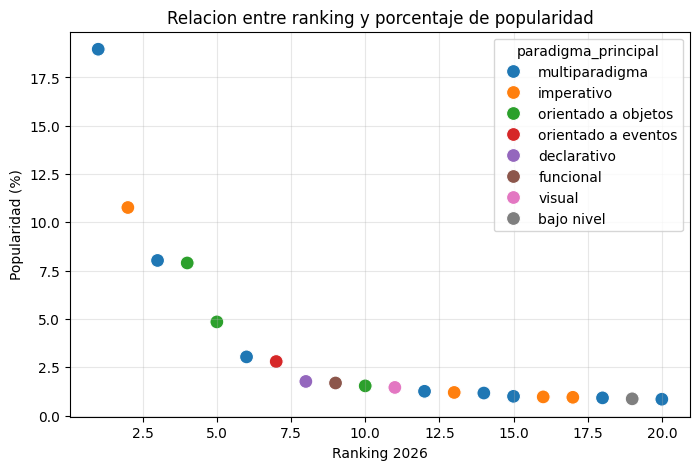

In [39]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_limpio, x='ranking_2026', y='porcentaje', hue='paradigma_principal', s=100)
plt.title('Relacion entre ranking y porcentaje de popularidad')
plt.xlabel('Ranking 2026')
plt.ylabel('Popularidad (%)')
plt.grid(alpha=0.3)
plt.show()

## Grafico del top 10

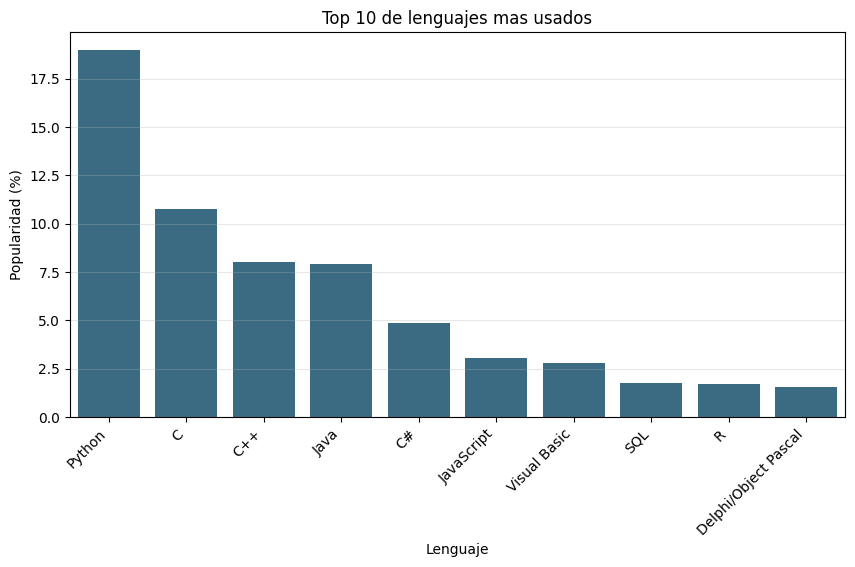

In [40]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top_10, x='lenguaje', y='porcentaje', color='#2f6f8f')
plt.title('Top 10 de lenguajes mas usados')
plt.xlabel('Lenguaje')
plt.ylabel('Popularidad (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Comparacion entre ranking 2026 y ranking 2025

In [41]:
df_limpio['cambio_posicion'] = df_limpio['ranking_2025'] - df_limpio['ranking_2026']

df_limpio[['lenguaje', 'ranking_2026', 'ranking_2025', 'cambio_posicion']].sort_values(
    'cambio_posicion', ascending=False
)

,lenguaje,ranking_2026,ranking_2025,cambio_posicion
14,Swift,15,25,10
11,Rust,12,18,6
8,R,9,14,5
10,Scratch,11,16,5
7,SQL,8,12,4
6,Visual Basic,7,8,1
13,PHP,14,15,1
1,C,2,3,1
18,Assembly language,19,19,0
3,Java,4,4,0


In [ ]:
cambios = df_limpio.sort_values('cambio_posicion', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=cambios, x='cambio_posicion', y='lenguaje', palette='viridis')
plt.title('Cambio de posicion respecto al ano anterior')
plt.xlabel('Posiciones ganadas o perdidas')
plt.ylabel('Lenguaje')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.show()

## Lenguajes que mas crecimiento y con mas caida

In [43]:
mas_crecieron = df_limpio.sort_values('variacion', ascending=False).head(5)
mas_bajaron = df_limpio.sort_values('variacion').head(5)

display(mas_crecieron[['lenguaje', 'porcentaje', 'variacion']])
display(mas_bajaron[['lenguaje', 'porcentaje', 'variacion']])

,lenguaje,porcentaje,variacion
1,C,10.77,1.30
6,Visual Basic,2.80,0.59
8,R,1.69,0.30
11,Rust,1.26,0.30
14,Swift,1.00,0.27


,lenguaje,porcentaje,variacion
0,Python,18.96,-6.91
2,C++,8.03,-2.65
12,Go,1.20,-1.08
3,Java,7.90,-0.94
16,Fortran,0.95,-0.91


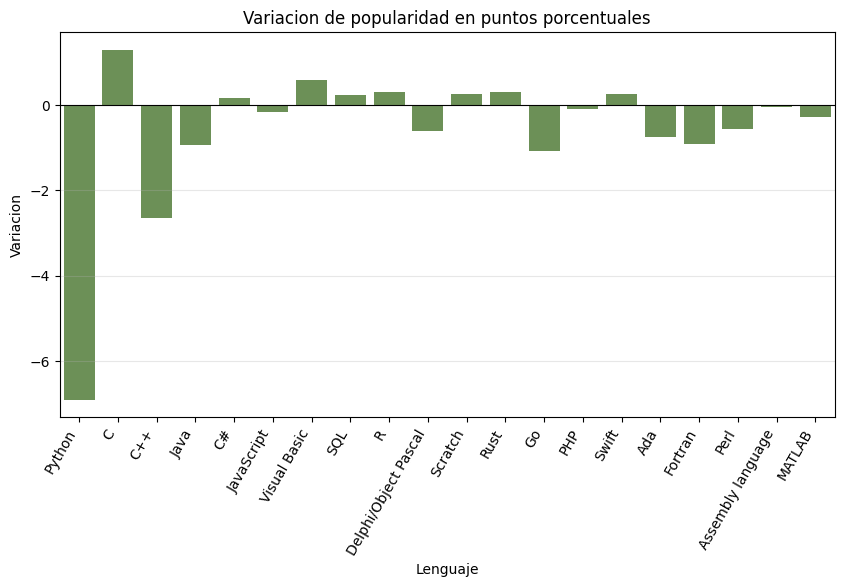

In [44]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_limpio, x='lenguaje', y='variacion', color='#6a994e')
plt.title('Variacion de popularidad en puntos porcentuales')
plt.xlabel('Lenguaje')
plt.ylabel('Variacion')
plt.xticks(rotation=60, ha='right')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Paradigmas principales

In [45]:
conteo_paradigmas = df_limpio['paradigma_principal'].value_counts().reset_index()
conteo_paradigmas.columns = ['paradigma_principal', 'cantidad']
conteo_paradigmas

,paradigma_principal,cantidad
0,multiparadigma,8
1,imperativo,4
2,orientado a objetos,3
3,orientado a eventos,1
4,declarativo,1
5,funcional,1
6,visual,1
7,bajo nivel,1


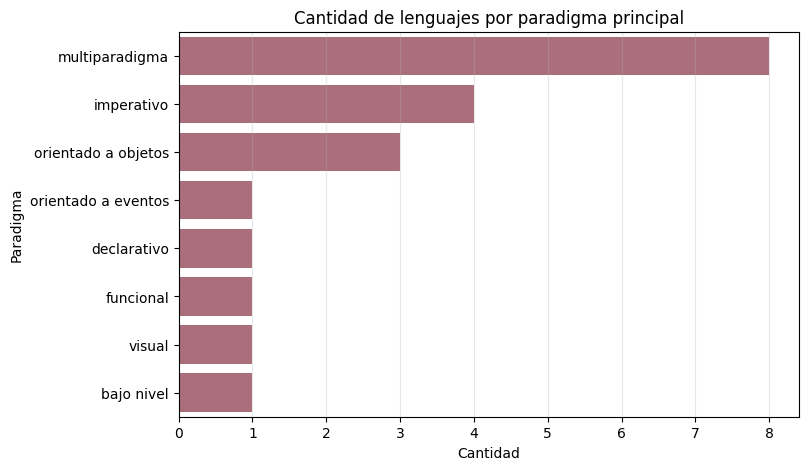

In [46]:
plt.figure(figsize=(8, 5))
sns.barplot(data=conteo_paradigmas, x='cantidad', y='paradigma_principal', color='#b56576')
plt.title('Cantidad de lenguajes por paradigma principal')
plt.xlabel('Cantidad')
plt.ylabel('Paradigma')
plt.grid(axis='x', alpha=0.3)
plt.show()

## Conclusion

El ranking muestra que Python ocupa el primer lugar entre los lenguajes mas populares, seguido por C, C++, Java y C#. Tambien se observa que algunos lenguajes subieron posiciones respecto del año anterior, como Swift, Rust, Scratch, R y SQL. 